# Neural Network Calibration Research: Wine Quality Dataset

**Research Question:** How well-calibrated are supervised neural networks on wine quality classification?

---

## 1. Introduction & Problem Statement

### Background

This notebook extends the calibration analysis to the **Wine Quality dataset**, investigating whether supervised neural networks exhibit similar calibration properties across different tabular domains.

### Dataset: Wine Quality

- **Task:** Binary classification - predict wine quality (Good ≥7 vs Bad <7)
- **Size:** ~6,500 samples (combining red and white wine)
- **Features:** 11 physicochemical features
- **Source:** UCI Machine Learning Repository

### Research Objectives

1. Establish supervised baseline performance on Wine Quality
2. Measure calibration quality using ECE and Brier Score  
3. Apply temperature scaling
4. Compare calibration properties with Adult Income dataset

## 2. Setup and Imports

In [2]:
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 3. Data Loading

In [4]:
def load_wine_quality_dataset():
    
    print("Downloading Wine Quality dataset...")
    red_wine = pd.read_csv('C:/Users/revku/Documents/Research paper/Datasets/wine+quality/winequality-red.csv', sep=';')
    white_wine = pd.read_csv('C:/Users/revku/Documents/Research paper/Datasets/wine+quality/winequality-white.csv', sep=';')
    
    # Add wine type column
    red_wine['wine_type'] = 1  # Red
    white_wine['wine_type'] = 0  # White
    
    # Combine datasets
    df = pd.concat([red_wine, white_wine], ignore_index=True)
    
    print(f"Dataset loaded successfully!")
    print(f"Total samples: {len(df)}")
    print(f"Red wine samples: {len(red_wine)}")
    print(f"White wine samples: {len(white_wine)}")
    
    return df

df = load_wine_quality_dataset()
df.head()

Dataset loaded successfully!
Total samples: 6497
Red wine samples: 1599
White wine samples: 4898


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


## 4. Exploratory Data Analysis

Dataset Shape: (6497, 13)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB
None

Quality Distribution:
quality
3      30


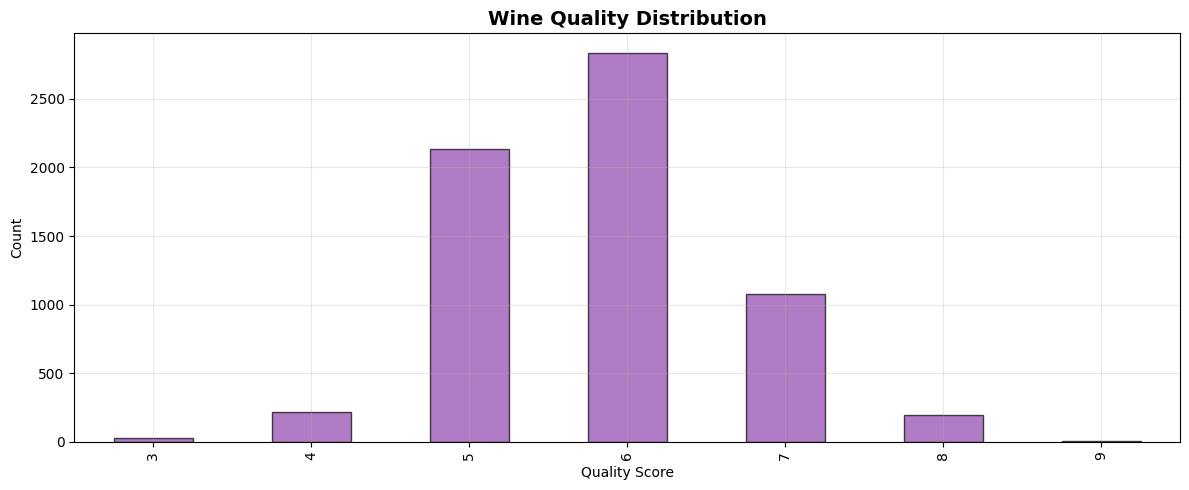

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nQuality Distribution:")
print(df['quality'].value_counts().sort_index())

# Visualize quality distribution
plt.figure(figsize=(12, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='#8e44ad', alpha=0.7, edgecolor='black')
plt.title('Wine Quality Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Binary Classification:
Bad wine (< 7): 5220 (80.3%)
Good wine (>= 7): 1277 (19.7%)


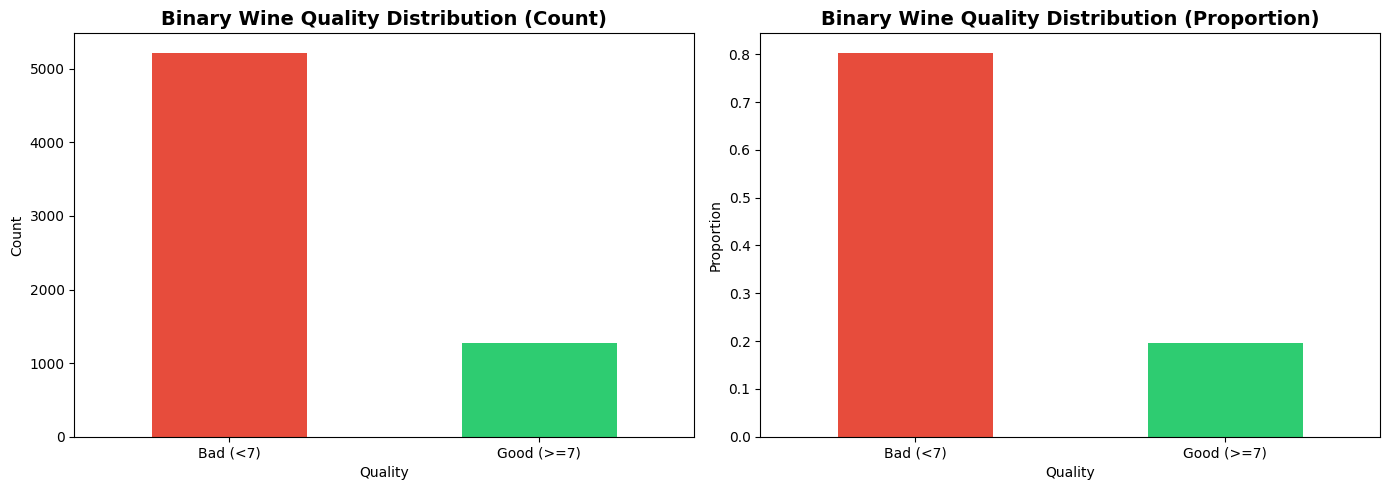

In [8]:
# Create binary classification target: Good (quality >= 7) vs Bad (quality < 7)
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("\nBinary Classification:")
print(f"Bad wine (< 7): {(df['quality_binary'] == 0).sum()} ({(df['quality_binary'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Good wine (>= 7): {(df['quality_binary'] == 1).sum()} ({(df['quality_binary'] == 1).sum()/len(df)*100:.1f}%)")

# Visualize binary distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['quality_binary'].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Binary Wine Quality Distribution (Count)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Quality')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Bad (<7)', 'Good (>=7)'], rotation=0)

df['quality_binary'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'])
ax[1].set_title('Binary Wine Quality Distribution (Proportion)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Quality')
ax[1].set_ylabel('Proportion')
ax[1].set_xticklabels(['Bad (<7)', 'Good (>=7)'], rotation=0)

plt.tight_layout()
plt.show()

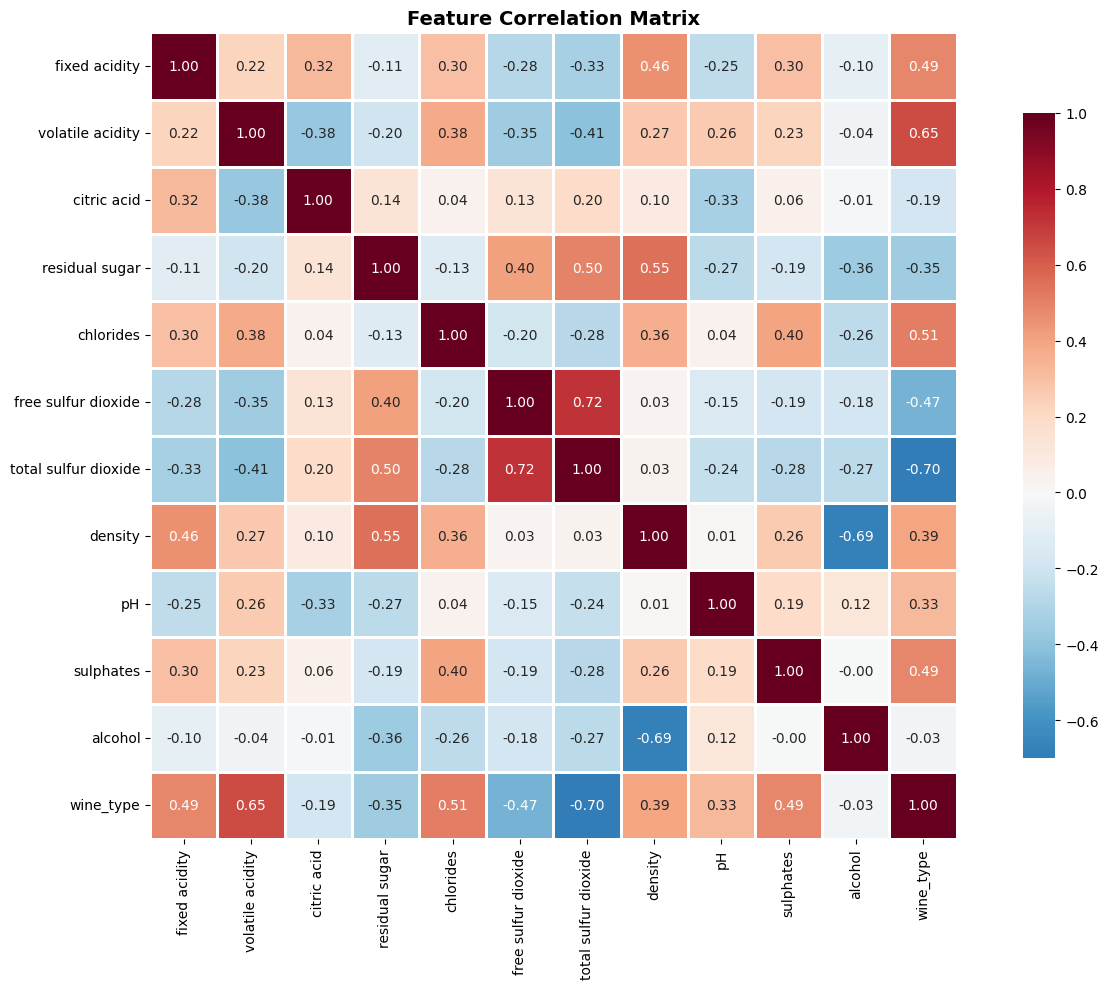

In [9]:
# Feature correlation heatmap
plt.figure(figsize=(14, 10))
feature_cols = [col for col in df.columns if col not in ['quality', 'quality_binary']]
correlation_matrix = df[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [11]:
def preprocess_wine_data(df):
    """
    Preprocess Wine Quality dataset
    """
    df = df.copy()
    
    # Separate features and target
    X = df.drop(['quality', 'quality_binary'], axis=1)
    y = df['quality_binary'].values
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    # Scale all features
    print("\nScaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_scaled = X_scaled.astype(np.float32)
    y = y.astype(np.int64)
    
    print("Preprocessing complete!")
    return X_scaled, y, scaler

X, y, scaler = preprocess_wine_data(df)

Features shape: (6497, 12)
Target shape: (6497,)
Class distribution: [5220 1277]

Scaling features...
Preprocessing complete!


## 6. Train/Validation/Test Split

In [13]:
# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Data Split:")
print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution:")
print(f"Train: {np.bincount(y_train)} -> {np.bincount(y_train)[1]/len(y_train)*100:.1f}% good")
print(f"Val: {np.bincount(y_val)} -> {np.bincount(y_val)[1]/len(y_val)*100:.1f}% good")
print(f"Test: {np.bincount(y_test)} -> {np.bincount(y_test)[1]/len(y_test)*100:.1f}% good")

Data Split:
Train: 3897 samples (60.0%)
Val: 1300 samples (20.0%)
Test: 1300 samples (20.0%)

Class distribution:
Train: [3131  766] -> 19.7% good
Val: [1045  255] -> 19.6% good
Test: [1044  256] -> 19.7% good


## 7. PyTorch Dataset

In [17]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch size: {batch_size}")

DataLoaders created with batch size: 128


## 8. MLP Model Architecture

In [18]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.3):
        super(MLPClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim2, 2)
        )
    
    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = MLPClassifier(input_dim).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Architecture:
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 10,050


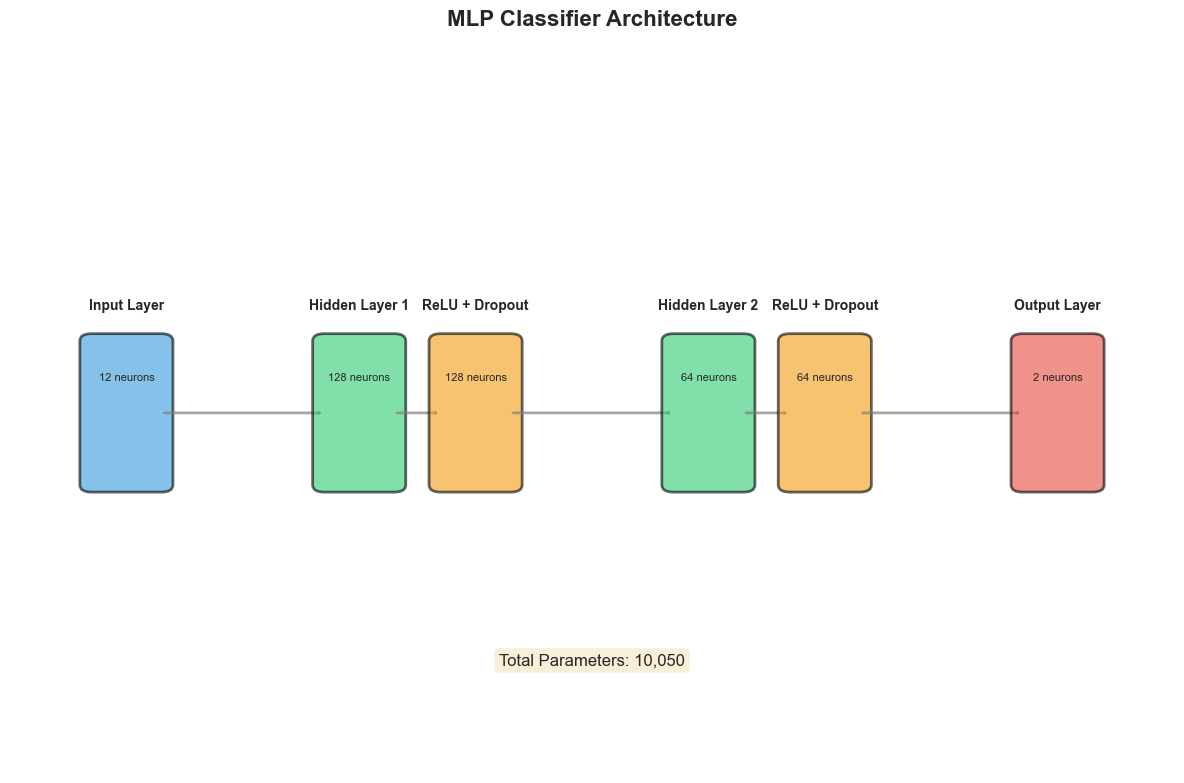

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_mlp_architecture(input_dim, hidden_dim1=128, hidden_dim2=64):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Define layer positions
    layers = [
        {'name': 'Input Layer', 'neurons': input_dim, 'x': 1, 'color': '#3498db'},
        {'name': 'Hidden Layer 1', 'neurons': hidden_dim1, 'x': 3, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim1, 'x': 4, 'color': '#f39c12'},
        {'name': 'Hidden Layer 2', 'neurons': hidden_dim2, 'x': 6, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim2, 'x': 7, 'color': '#f39c12'},
        {'name': 'Output Layer', 'neurons': 2, 'x': 9, 'color': '#e74c3c'}
    ]
    
    # Draw layers
    for i, layer in enumerate(layers):
        # Draw box
        box = FancyBboxPatch(
            (layer['x'] - 0.3, 4), 0.6, 2,
            boxstyle="round,pad=0.1",
            edgecolor='black',
            facecolor=layer['color'],
            alpha=0.6,
            linewidth=2
        )
        ax.add_patch(box)
        
        # Add text
        ax.text(layer['x'], 6.5, layer['name'], 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(layer['x'], 5.5, f"{layer['neurons']} neurons", 
                ha='center', va='center', fontsize=8)
        
        # Draw arrows between layers
        if i < len(layers) - 1:
            arrow = FancyArrowPatch(
                (layer['x'] + 0.3, 5),
                (layers[i+1]['x'] - 0.3, 5),
                arrowstyle='->,head_width=0.4,head_length=0.4',
                color='gray',
                linewidth=2,
                alpha=0.7
            )
            ax.add_patch(arrow)
    
    # Add title
    plt.title('MLP Classifier Architecture', fontsize=16, fontweight='bold', pad=20)
    
    # Add legend
    total_params = sum(p.numel() for p in model.parameters())
    legend_text = f'Total Parameters: {total_params:,}'
    ax.text(5, 1.5, legend_text, ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('mlp_architecture_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize
visualize_mlp_architecture(input_dim)

## 9. Training Pipeline

In [20]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    
    print("Starting training...\n")
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(logits.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = correct / total
        
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    print("\nTraining complete!")
    return history

history = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)

Starting training...

Epoch [5/30] - Train Loss: 0.3860, Val Loss: 0.3926, Val Acc: 0.8277
Epoch [10/30] - Train Loss: 0.3599, Val Loss: 0.3832, Val Acc: 0.8285
Epoch [15/30] - Train Loss: 0.3515, Val Loss: 0.3784, Val Acc: 0.8262
Epoch [20/30] - Train Loss: 0.3479, Val Loss: 0.3708, Val Acc: 0.8215
Epoch [25/30] - Train Loss: 0.3409, Val Loss: 0.3710, Val Acc: 0.8277
Epoch [30/30] - Train Loss: 0.3316, Val Loss: 0.3712, Val Acc: 0.8277

Training complete!


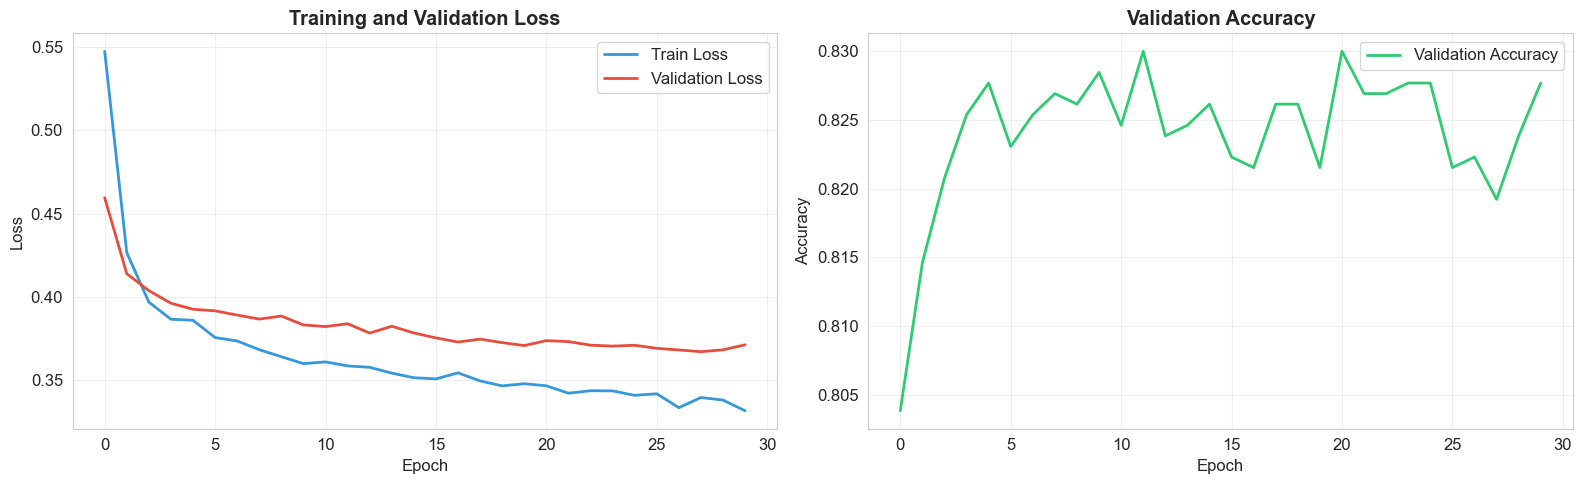

In [21]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#3498db')
ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#e74c3c')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#2ecc71')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10-16. Performance Evaluation, Calibration Metrics, Temperature Scaling

*(Following the same structure as Adult Income notebook)*

                    DETAILED PERFORMANCE REPORT

Metric                    Value          
----------------------------------------
Accuracy                  0.8285
Precision                 0.6187
Recall (Sensitivity)      0.3359
F1-Score                  0.4354
AUC-ROC                   0.8427
Average Precision         0.5639

Confusion Matrix:
----------------------------------------
True Negatives (TN):      991
False Positives (FP):     53
False Negatives (FN):     170
True Positives (TP):      86

Additional Metrics:
----------------------------------------
Specificity               0.9492
False Positive Rate       0.0508
False Negative Rate       0.6641

Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K     0.8536    0.9492    0.8989      1044
        >50K     0.6187    0.3359    0.4354       256

    accuracy                         0.8285      1300
   macro avg     0

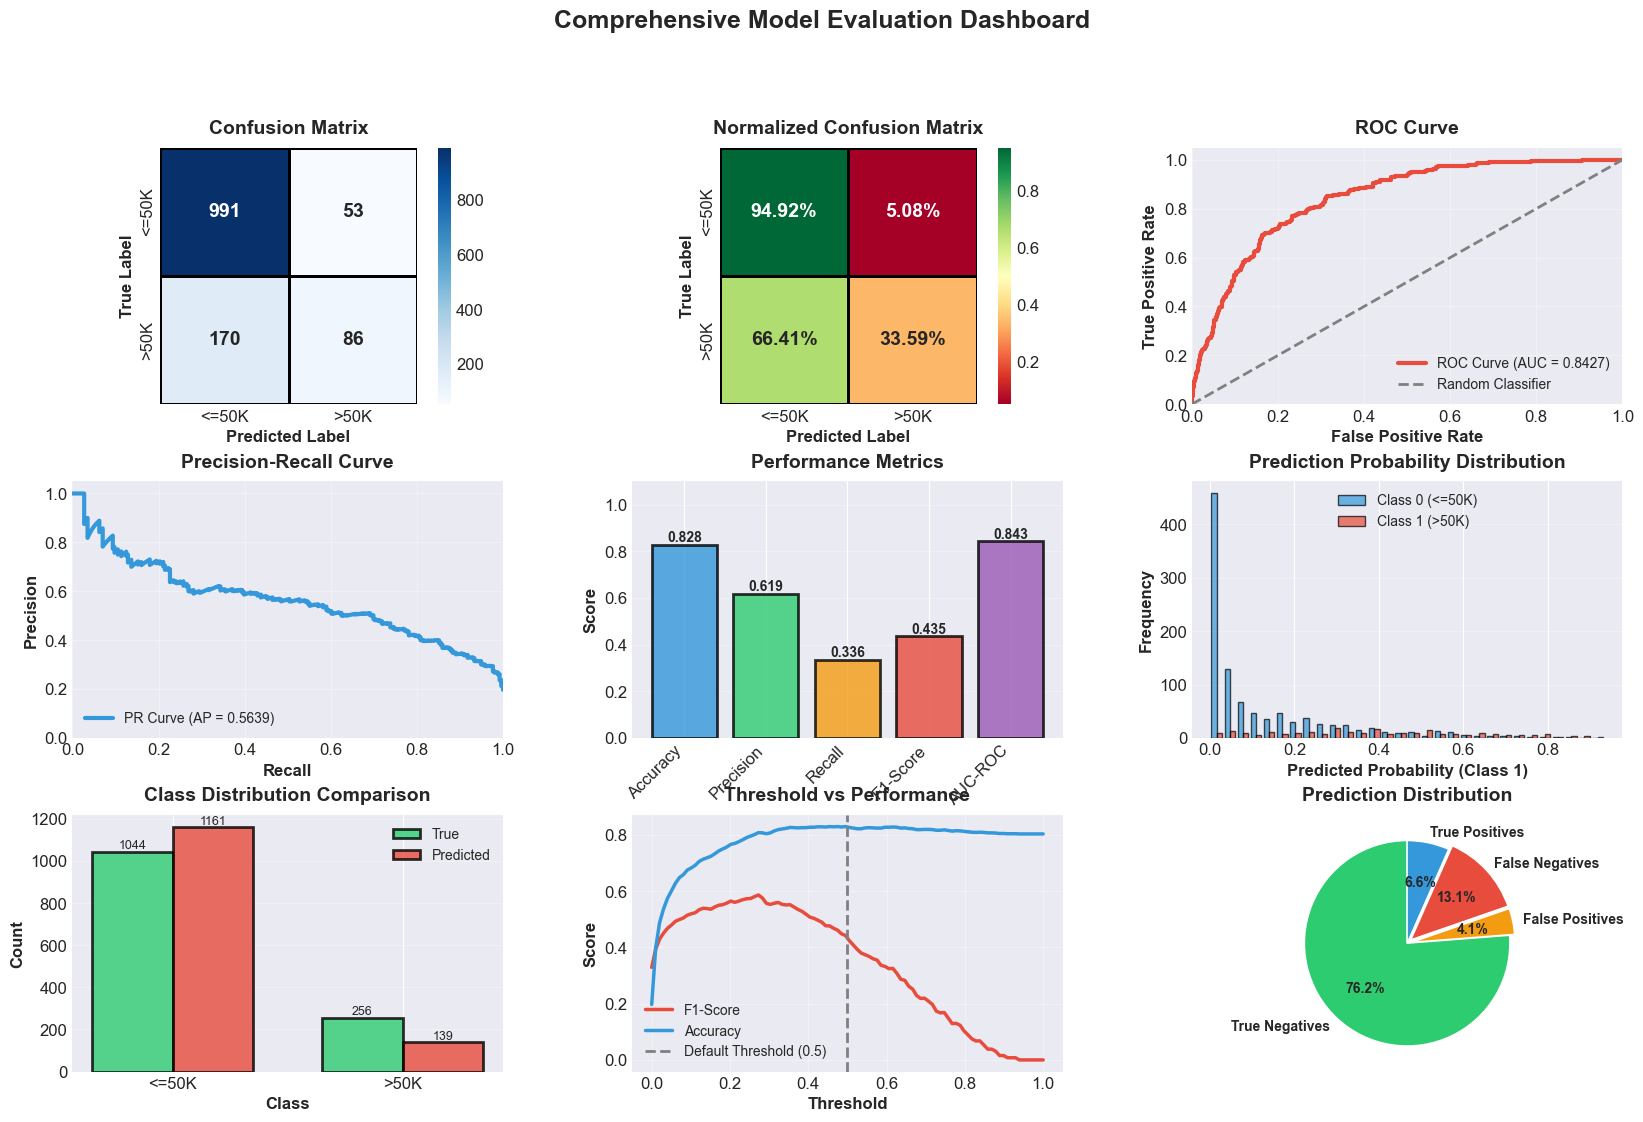

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score, precision_score, recall_score
)
import numpy as np

def evaluate_model(model, dataloader):
    """
    Evaluate model and return predictions, probabilities, and labels
    """
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    all_logits = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_logits.extend(logits.cpu().numpy())
    
    return (
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels),
        np.array(all_logits)
    )

def plot_comprehensive_evaluation(y_true, y_pred, y_prob, save_path='evaluation_results.png'):
    """
    Create comprehensive visualization of model performance
    """
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    cm = confusion_matrix(y_true, y_pred)
    
    # 1. Confusion Matrix (Enhanced)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax1)
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xticklabels(['<=50K', '>50K'])
    ax1.set_yticklabels(['<=50K', '>50K'])
    
    # 2. Normalized Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
                cbar=True, square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax2)
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax2.set_xticklabels(['<=50K', '>50K'])
    ax2.set_yticklabels(['<=50K', '>50K'])
    
    # 3. ROC Curve
    ax3 = fig.add_subplot(gs[0, 2])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])
    ax3.plot(fpr, tpr, color='#e74c3c', linewidth=3, 
             label=f'ROC Curve (AUC = {auc_roc:.4f})')
    ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, 
             label='Random Classifier')
    ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=10)
    ax3.legend(loc='lower right', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    
    # 4. Precision-Recall Curve
    ax4 = fig.add_subplot(gs[1, 0])
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob[:, 1])
    ax4.plot(recall_curve, precision_curve, color='#3498db', linewidth=3,
             label=f'PR Curve (AP = {avg_precision:.4f})')
    ax4.set_xlabel('Recall', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax4.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', pad=10)
    ax4.legend(loc='lower left', fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    
    # 5. Metrics Bar Chart
    ax5 = fig.add_subplot(gs[1, 1])
    metrics_dict = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
    bars = ax5.bar(metrics_dict.keys(), metrics_dict.values(), color=colors, 
                   edgecolor='black', linewidth=2, alpha=0.8)
    ax5.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax5.set_title('Performance Metrics', fontsize=14, fontweight='bold', pad=10)
    ax5.set_ylim([0, 1.1])
    ax5.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 6. Prediction Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist([y_prob[y_true == 0, 1], y_prob[y_true == 1, 1]], 
             bins=30, label=['Class 0 (<=50K)', 'Class 1 (>50K)'],
             color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
    ax6.set_xlabel('Predicted Probability (Class 1)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax6.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold', pad=10)
    ax6.legend(loc='upper center', fontsize=10)
    ax6.grid(True, alpha=0.3, axis='y')
    
    # 7. Class Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    class_counts_true = np.bincount(y_true)
    class_counts_pred = np.bincount(y_pred)
    x = np.arange(2)
    width = 0.35
    bars1 = ax7.bar(x - width/2, class_counts_true, width, label='True', 
                    color='#2ecc71', edgecolor='black', linewidth=2, alpha=0.8)
    bars2 = ax7.bar(x + width/2, class_counts_pred, width, label='Predicted', 
                    color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)
    ax7.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax7.set_title('Class Distribution Comparison', fontsize=14, fontweight='bold', pad=10)
    ax7.set_xticks(x)
    ax7.set_xticklabels(['<=50K', '>50K'])
    ax7.legend(fontsize=10)
    ax7.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax7.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # 8. Threshold Analysis
    ax8 = fig.add_subplot(gs[2, 1])
    thresholds_range = np.linspace(0, 1, 100)
    f1_scores = []
    accuracies = []
    
    for threshold in thresholds_range:
        y_pred_thresh = (y_prob[:, 1] >= threshold).astype(int)
        f1_scores.append(f1_score(y_true, y_pred_thresh))
        accuracies.append(accuracy_score(y_true, y_pred_thresh))
    
    ax8.plot(thresholds_range, f1_scores, label='F1-Score', 
             color='#e74c3c', linewidth=2.5)
    ax8.plot(thresholds_range, accuracies, label='Accuracy', 
             color='#3498db', linewidth=2.5)
    ax8.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, 
                label='Default Threshold (0.5)')
    ax8.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax8.set_title('Threshold vs Performance', fontsize=14, fontweight='bold', pad=10)
    ax8.legend(loc='best', fontsize=10)
    ax8.grid(True, alpha=0.3)
    
    # 9. Error Analysis
    ax9 = fig.add_subplot(gs[2, 2])
    error_types = {
        'True Negatives': cm[0, 0],
        'False Positives': cm[0, 1],
        'False Negatives': cm[1, 0],
        'True Positives': cm[1, 1]
    }
    colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    wedges, texts, autotexts = ax9.pie(error_types.values(), labels=error_types.keys(),
                                        autopct='%1.1f%%', startangle=90,
                                        colors=colors_pie, explode=(0, 0.05, 0.05, 0),
                                        textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax9.set_title('Prediction Distribution', fontsize=14, fontweight='bold', pad=10)
    
    # Overall title
    fig.suptitle('Comprehensive Model Evaluation Dashboard', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics_dict

def print_detailed_report(y_true, y_pred, y_prob):
    """
    Print detailed classification report
    """
    print("="*70)
    print(" "*20 + "DETAILED PERFORMANCE REPORT")
    print("="*70)
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    
    print(f"\n{'Metric':<25} {'Value':<15}")
    print("-"*40)
    print(f"{'Accuracy':<25} {accuracy:.4f}")
    print(f"{'Precision':<25} {precision:.4f}")
    print(f"{'Recall (Sensitivity)':<25} {recall:.4f}")
    print(f"{'F1-Score':<25} {f1:.4f}")
    print(f"{'AUC-ROC':<25} {auc_roc:.4f}")
    print(f"{'Average Precision':<25} {avg_precision:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'Confusion Matrix:'}")
    print("-"*40)
    print(f"{'True Negatives (TN):':<25} {cm[0, 0]}")
    print(f"{'False Positives (FP):':<25} {cm[0, 1]}")
    print(f"{'False Negatives (FN):':<25} {cm[1, 0]}")
    print(f"{'True Positives (TP):':<25} {cm[1, 1]}")
    
    # Additional metrics
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    print(f"\n{'Additional Metrics:'}")
    print("-"*40)
    print(f"{'Specificity':<25} {specificity:.4f}")
    print(f"{'False Positive Rate':<25} {1 - specificity:.4f}")
    print(f"{'False Negative Rate':<25} {1 - recall:.4f}")
    
    # Classification report
    print(f"\n{'Classification Report:'}")
    print("-"*70)
    print(classification_report(y_true, y_pred, 
                                target_names=['<=50K', '>50K'],
                                digits=4))
    
    print("="*70)

# Evaluate on test set
y_pred, y_prob, y_true, y_logits = evaluate_model(model, test_loader)

# Print detailed report
print_detailed_report(y_true, y_pred, y_prob)

# Create comprehensive visualizations
metrics = plot_comprehensive_evaluation(y_true, y_pred, y_prob, 
                                        save_path='model_evaluation_dashboard.png')

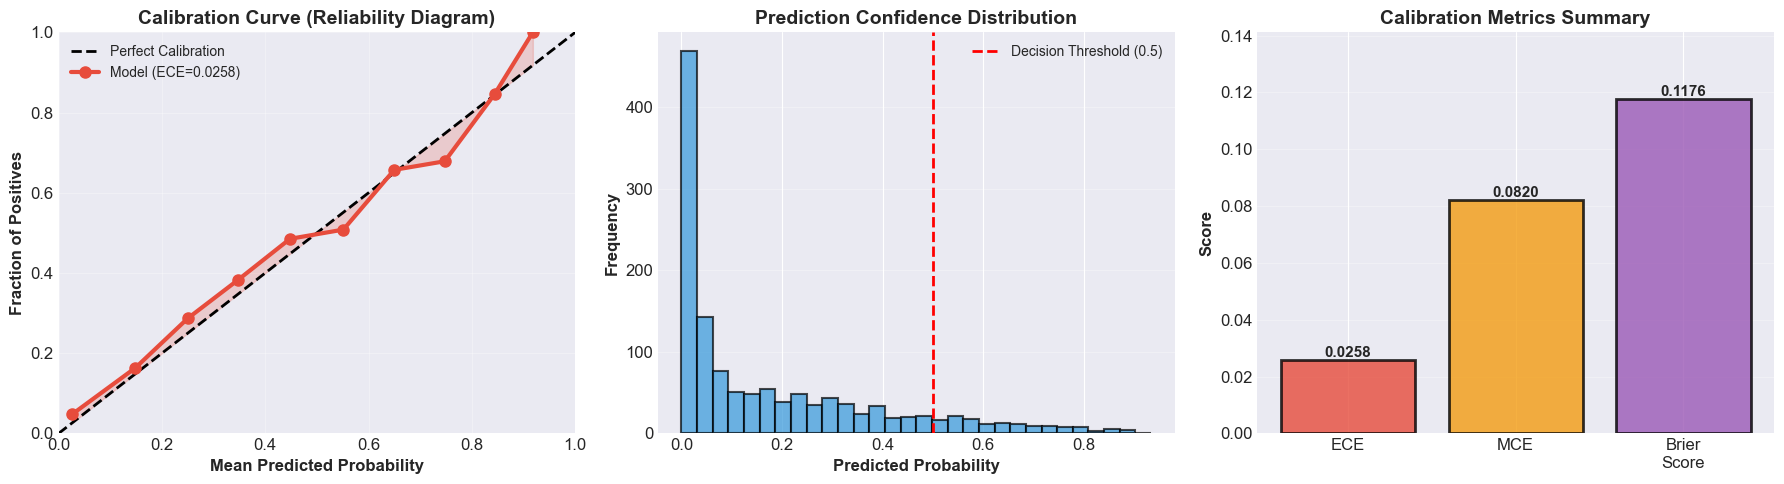

CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0258
Maximum Calibration Error (MCE):  0.0820
Brier Score:                       0.1176

INTERPRETATION:
✓ ECE < 0.05: Excellent calibration
⚠ Brier Score < 0.20: Good probability estimates


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
y_prob_pos = y_prob[:, 1]
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.mean(mask)
    return ece


def maximum_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    mce = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            mce = max(mce, np.abs(acc - conf))
    return mce

def plot_calibration_metrics(y_true, y_prob_pos, n_bins=10):
    """
    Visualize calibration metrics with simple plots
    """
    # Calculate calibration metrics
    ece = expected_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    brier = brier_score_loss(y_true, y_prob_pos)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Reliability Diagram (Calibration Curve)
    ax1 = axes[0]
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob_pos, n_bins=n_bins, strategy='uniform'
    )
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.plot(mean_predicted_value, fraction_of_positives, 
             'o-', color='#e74c3c', linewidth=3, markersize=8,
             label=f'Model (ECE={ece:.4f})')
    ax1.fill_between(mean_predicted_value, fraction_of_positives, 
                      mean_predicted_value, alpha=0.2, color='#e74c3c')
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
    ax1.set_title('Calibration Curve (Reliability Diagram)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    # 2. Confidence Histogram
    ax2 = axes[1]
    ax2.hist(y_prob_pos, bins=30, color='#3498db', alpha=0.7, 
             edgecolor='black', linewidth=1.5)
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                label='Decision Threshold (0.5)')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Confidence Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Calibration Metrics Bar Chart
    ax3 = axes[2]
    metrics = {
        'ECE': ece,
        'MCE': mce,
        'Brier\nScore': brier
    }
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax3.bar(metrics.keys(), metrics.values(), 
                   color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax3.set_title('Calibration Metrics Summary', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, max(metrics.values()) * 1.2])
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('calibration_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print metrics
    print("="*60)
    print("CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)")
    print("="*60)
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE):  {mce:.4f}")
    print(f"Brier Score:                       {brier:.4f}")
    print("="*60)
    
    # Interpretation
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    if ece < 0.05:
        print("✓ ECE < 0.05: Excellent calibration")
    elif ece < 0.10:
        print("⚠ ECE < 0.10: Good calibration")
    else:
        print("✗ ECE ≥ 0.10: Poor calibration - consider calibration methods")
    
    if brier < 0.10:
        print("✓ Brier Score < 0.10: Excellent probability estimates")
    elif brier < 0.20:
        print("⚠ Brier Score < 0.20: Good probability estimates")
    else:
        print("✗ Brier Score ≥ 0.20: Poor probability estimates")
    print("="*60)

# Visualize calibration
plot_calibration_metrics(y_true, y_prob_pos, n_bins=10)

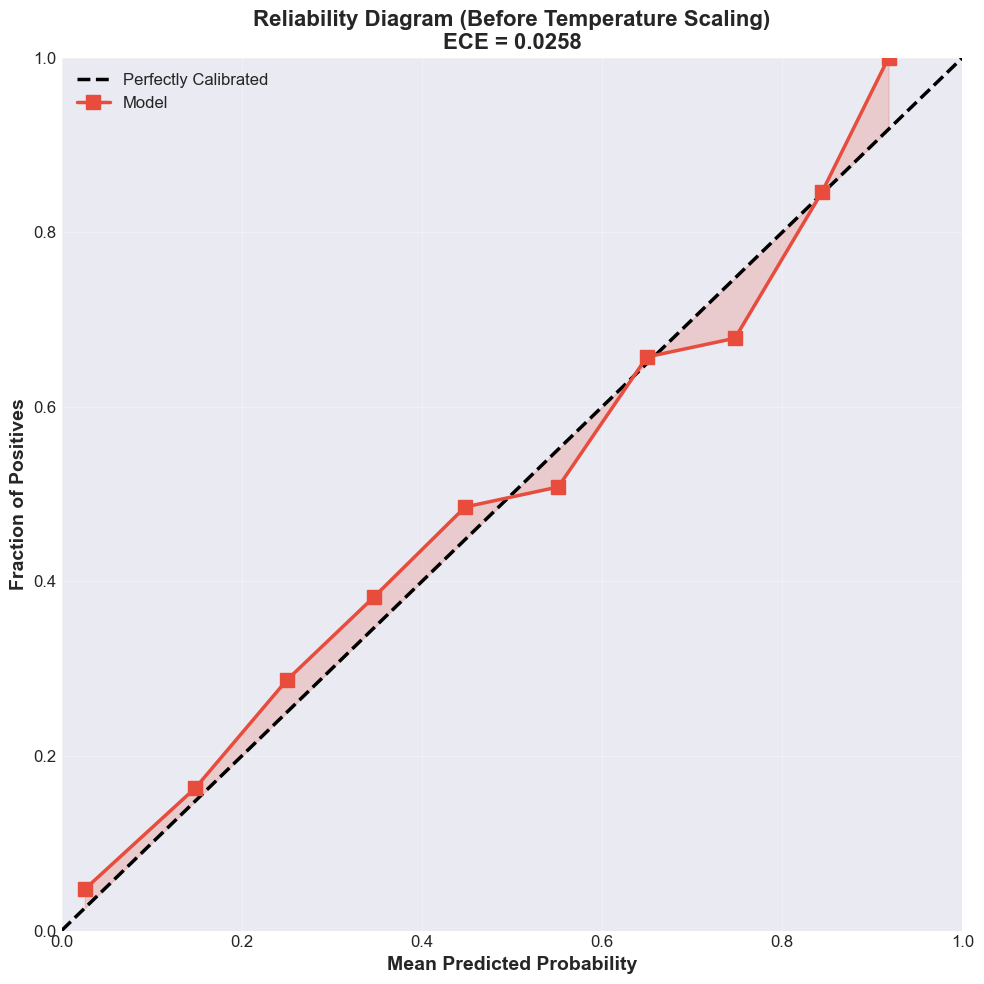

In [28]:
def plot_reliability_diagram(y_true, y_prob, n_bins=10, title='Reliability Diagram'):
    """
    Plot reliability diagram
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Calculate calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )
    
    # Plot perfectly calibrated line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
    
    # Plot model calibration
    ax.plot(mean_predicted_value, fraction_of_positives, 's-', 
            label='Model', linewidth=2.5, markersize=10, color='#e74c3c')
    
    # Fill gap area
    ax.fill_between(mean_predicted_value, fraction_of_positives, mean_predicted_value,
                     alpha=0.2, color='#e74c3c')
    
    ece_val = expected_calibration_error(y_true, y_prob, n_bins)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
    ax.set_title(f'{title}\nECE = {ece_val:.4f}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

# Plot reliability diagram for uncalibrated model
plot_reliability_diagram(y_true, y_prob_pos, n_bins=10, 
                         title='Reliability Diagram (Before Temperature Scaling)')

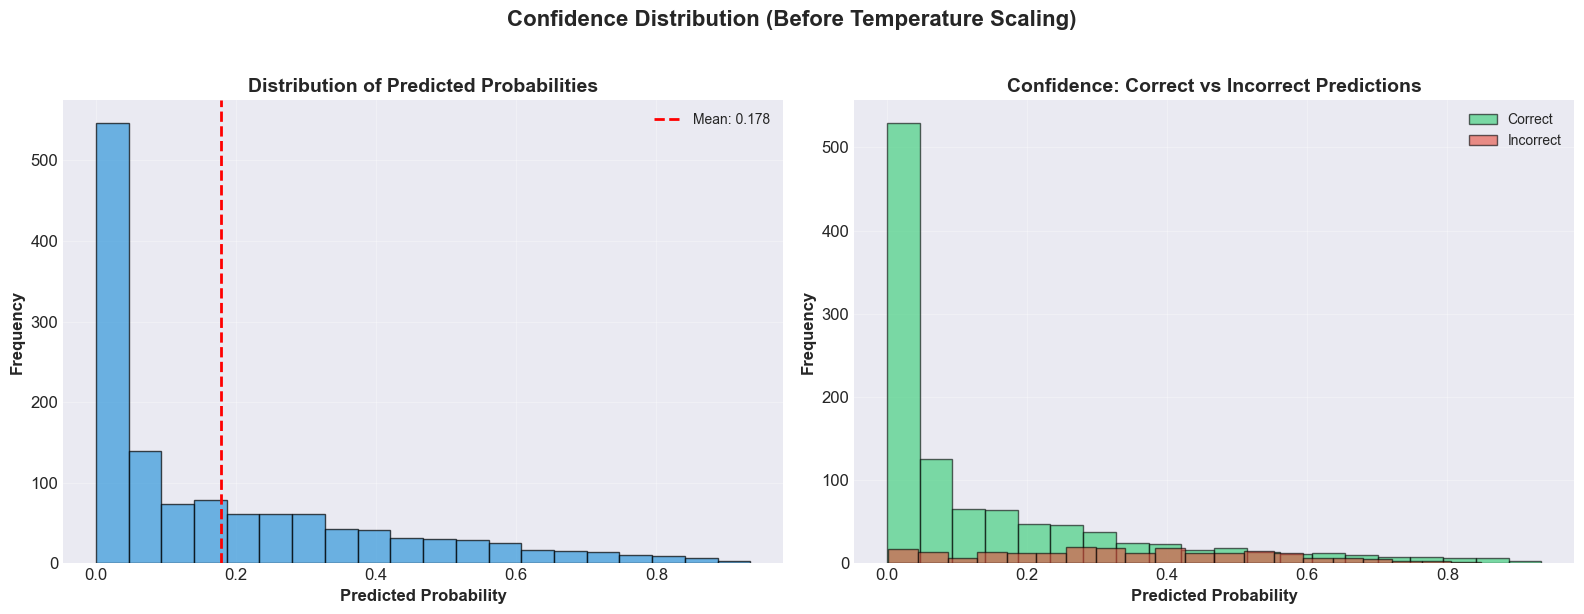

In [29]:
def plot_confidence_histogram(y_true, y_prob, title='Confidence Distribution'):
    """
    Plot histogram of prediction confidences
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram for all predictions
    ax1.hist(y_prob, bins=20, alpha=0.7, edgecolor='black', color='#3498db')
    ax1.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axvline(y_prob.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_prob.mean():.3f}')
    ax1.legend(fontsize=10)
    
    # Separate histograms for correct and incorrect predictions
    correct_mask = (y_prob > 0.5) == y_true
    
    ax2.hist(y_prob[correct_mask], bins=20, alpha=0.6, label='Correct', 
             edgecolor='black', color='#2ecc71')
    ax2.hist(y_prob[~correct_mask], bins=20, alpha=0.6, label='Incorrect', 
             edgecolor='black', color='#e74c3c')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot confidence histogram
plot_confidence_histogram(y_true, y_prob_pos, 
                          title='Confidence Distribution (Before Temperature Scaling)')

In [30]:
class TemperatureScaling(nn.Module):
    """
    Temperature scaling for model calibration
    """
    def __init__(self):
        super(TemperatureScaling, self).__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    
    def forward(self, logits):
        return logits / self.temperature

def learn_temperature(logits, labels, max_iter=50, lr=0.01):
    """
    Learn optimal temperature parameter using LBFGS
    """
    nll_criterion = nn.CrossEntropyLoss()
    temp_model = TemperatureScaling()
    optimizer = optim.LBFGS([temp_model.temperature], lr=lr, max_iter=max_iter)
    
    logits = torch.FloatTensor(logits)
    labels = torch.LongTensor(labels)
    
    def eval_loss():
        optimizer.zero_grad()
        loss = nll_criterion(temp_model(logits), labels)
        loss.backward()
        return loss
    
    optimizer.step(eval_loss)
    
    temperature = temp_model.temperature.item()
    return temperature

# Get validation logits for temperature scaling
_, _, y_val_true, y_val_logits = evaluate_model(model, val_loader)

# Learn temperature on validation set
print("Learning temperature parameter on validation set...")
temperature = learn_temperature(y_val_logits, y_val_true)
print(f"Learned temperature: {temperature:.4f}")

Learning temperature parameter on validation set...
Learned temperature: 1.3196


In [31]:
# Apply temperature scaling to test set
def apply_temperature_scaling(logits, temperature):
    """
    Apply temperature scaling to logits
    """
    scaled_logits = torch.FloatTensor(logits) / temperature
    probs = torch.softmax(scaled_logits, dim=1)
    return probs.numpy()

# Get calibrated probabilities
y_prob_calibrated = apply_temperature_scaling(y_logits, temperature)
y_prob_calibrated_pos = y_prob_calibrated[:, 1]

# Calculate calibration metrics after temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

print("="*60)
print("CALIBRATION METRICS (AFTER TEMPERATURE SCALING)")
print("="*60)
print(f"Expected Calibration Error (ECE): {ece_after:.4f}")
print(f"Maximum Calibration Error (MCE):  {mce_after:.4f}")
print(f"Brier Score:                       {brier_after:.4f}")
print("="*60)

CALIBRATION METRICS (AFTER TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0189
Maximum Calibration Error (MCE):  0.1615
Brier Score:                       0.1172


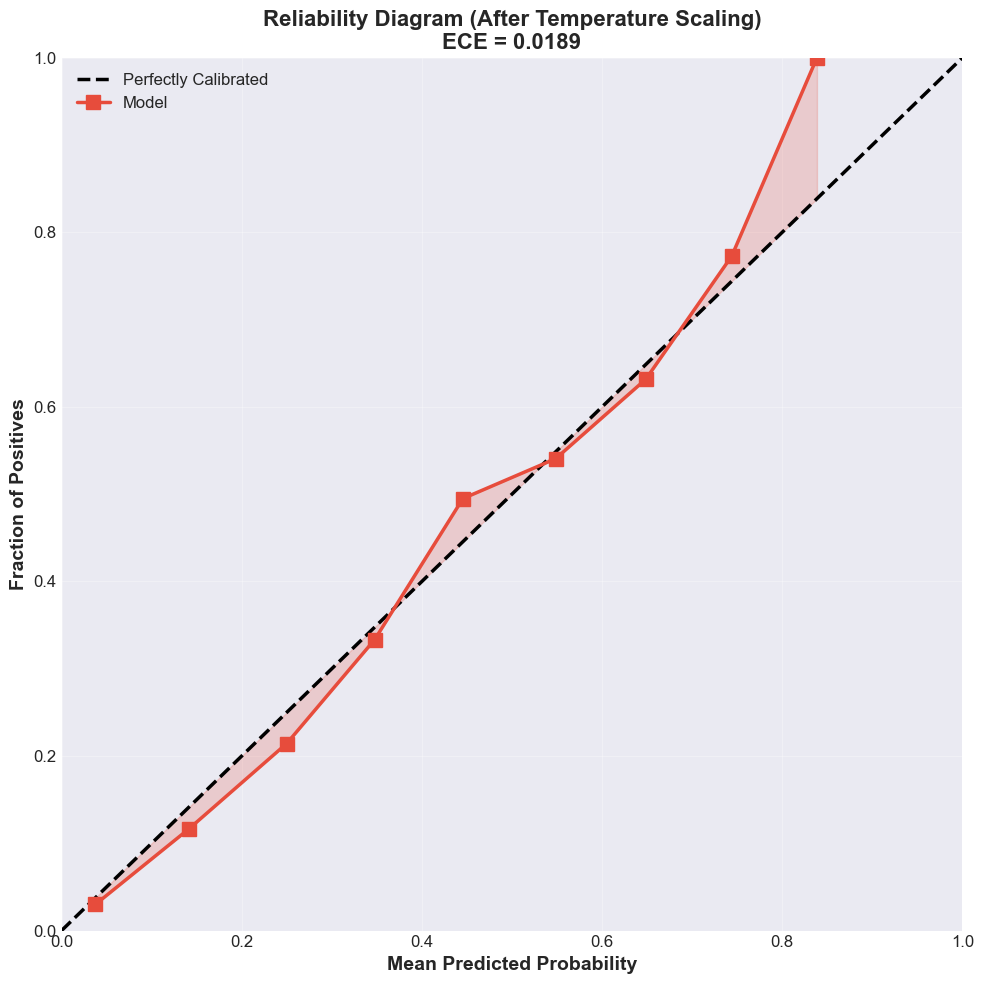

In [32]:
# Reliability diagram after temperature scaling
plot_reliability_diagram(y_true, y_prob_calibrated_pos, n_bins=10,
                         title='Reliability Diagram (After Temperature Scaling)')

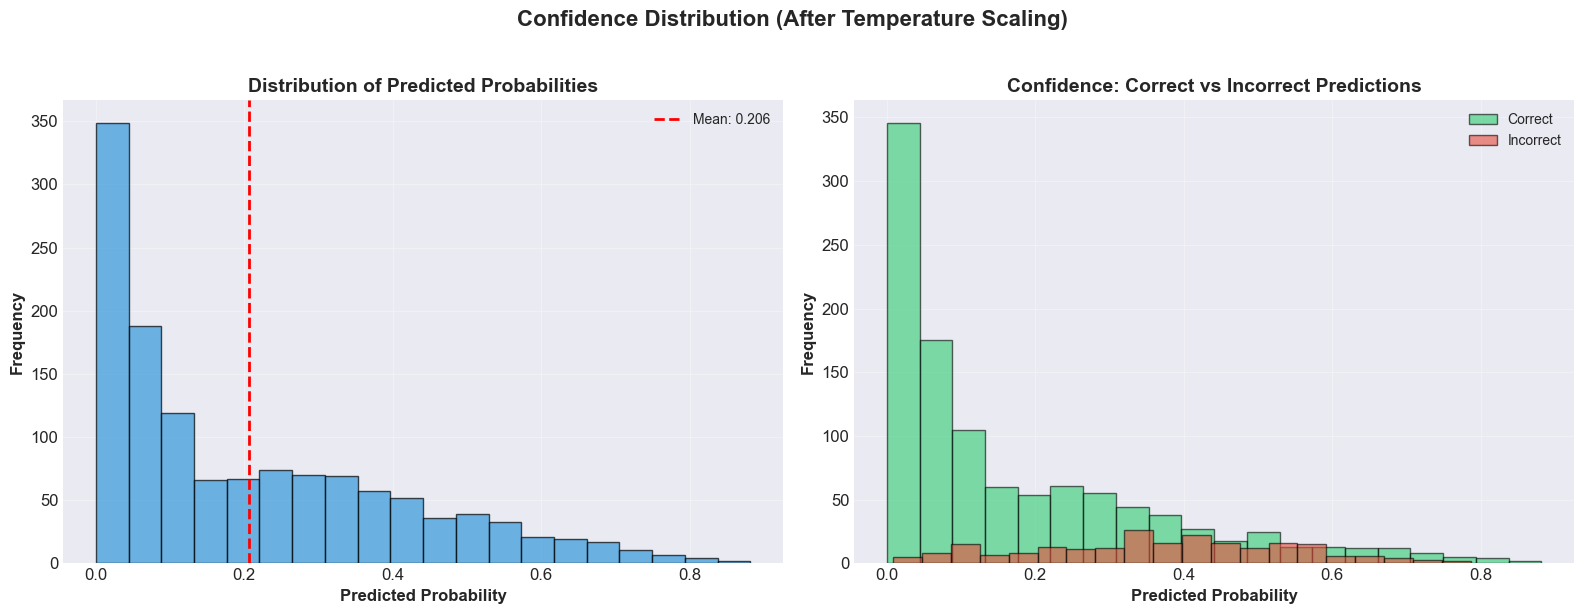

In [33]:
# Confidence histogram after temperature scaling
plot_confidence_histogram(y_true, y_prob_calibrated_pos,
                          title='Confidence Distribution (After Temperature Scaling)')

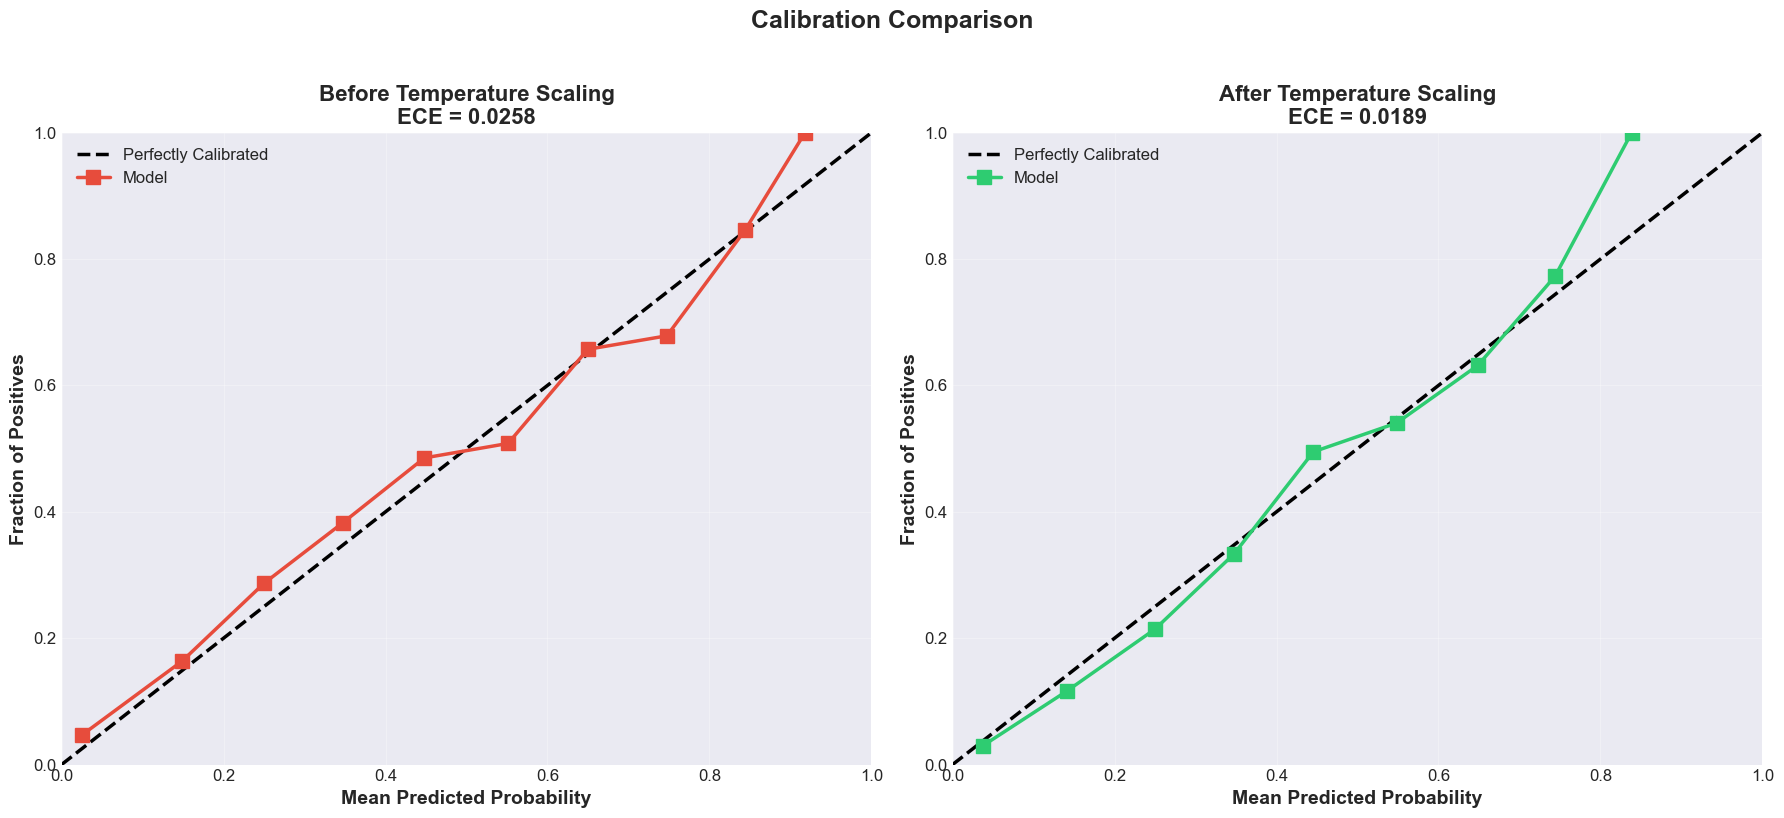

In [36]:
# Compute calibration errors
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before temperature scaling
fraction_of_positives_before, mean_predicted_value_before = calibration_curve(
    y_true, y_prob_pos, n_bins=10, strategy='uniform'
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
axes[0].plot(mean_predicted_value_before, fraction_of_positives_before, 's-',
             label='Model', linewidth=2.5, markersize=10, color='#e74c3c')
axes[0].set_title(f'Before Temperature Scaling\nECE = {ece:.4f}',
                  fontsize=16, fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# After temperature scaling
fraction_of_positives_after, mean_predicted_value_after = calibration_curve(
    y_true, y_prob_calibrated_pos, n_bins=10, strategy='uniform'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
axes[1].plot(mean_predicted_value_after, fraction_of_positives_after, 's-',
             label='Model', linewidth=2.5, markersize=10, color='#2ecc71')
axes[1].set_title(f'After Temperature Scaling\nECE = {ece_after:.4f}',
                  fontsize=16, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Calibration Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [34]:
# Improvement metrics
from sklearn.metrics import brier_score_loss

# Before calibration
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=10)
brier = brier_score_loss(y_true, y_prob_pos)

# After temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

ece_improvement = (ece - ece_after) / ece * 100
brier_improvement = (brier - brier_after) / brier * 100

print("="*60)
print("CALIBRATION IMPROVEMENT SUMMARY")
print("="*60)
print(f"ECE:         {ece:.4f} → {ece_after:.4f} ({ece_improvement:+.1f}%)")
print(f"MCE:         {mce:.4f} → {mce_after:.4f}")
print(f"Brier Score: {brier:.4f} → {brier_after:.4f} ({brier_improvement:+.1f}%)")
print(f"\nTemperature: {temperature:.4f}")
print("="*60)

CALIBRATION IMPROVEMENT SUMMARY
ECE:         0.0258 → 0.0189 (+26.9%)
MCE:         0.0820 → 0.1615
Brier Score: 0.1176 → 0.1172 (+0.4%)

Temperature: 1.3196


In [37]:
# Create comprehensive results table
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

# Performance metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob[:, 1])

# Calibration metrics (before)
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=10)
brier = brier_score_loss(y_true, y_prob_pos)

# Calibration metrics (after temperature scaling)
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

# Improvements (safe division)
ece_improvement = ((ece - ece_after) / ece * 100) if ece > 0 else 0.0
brier_improvement = ((brier - brier_after) / brier * 100) if brier > 0 else 0.0

results_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'F1-Score',
        'AUC-ROC',
        'ECE (Before)',
        'ECE (After)',
        'ECE Improvement (%)',
        'Brier Score (Before)',
        'Brier Score (After)',
        'Brier Improvement (%)',
        'Temperature',
        'Architecture',
        'Total Parameters',
        'Training Epochs',
        'Optimizer'
    ],
    'Value': [
        f"{accuracy:.4f}",
        f"{f1:.4f}",
        f"{auc:.4f}",
        f"{ece:.4f}",
        f"{ece_after:.4f}",
        f"{ece_improvement:.1f}%",
        f"{brier:.4f}",
        f"{brier_after:.4f}",
        f"{brier_improvement:.1f}%",
        f"{temperature:.4f}",
        'MLP (128-64-2)',
        f"{sum(p.numel() for p in model.parameters()):,}",
        '30',
        'Adam (lr=0.001)'
    ]
})

print("\n" + "="*60)
print("WINE QUALITY DATASET - COMPREHENSIVE RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)



WINE QUALITY DATASET - COMPREHENSIVE RESULTS
               Metric           Value
             Accuracy          0.8285
             F1-Score          0.4354
              AUC-ROC          0.8427
         ECE (Before)          0.0258
          ECE (After)          0.0189
  ECE Improvement (%)           26.9%
 Brier Score (Before)          0.1176
  Brier Score (After)          0.1172
Brier Improvement (%)            0.4%
          Temperature          1.3196
         Architecture  MLP (128-64-2)
     Total Parameters          10,050
      Training Epochs              30
            Optimizer Adam (lr=0.001)
